In [1]:
#
# !!! RUN THIS FIRST !!!
#
# (loads the data and defines all necessary functions)
#


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', 20)  # long tables show head/tail with '...' automatically

df = pd.read_csv('data/rc_circuit_data.csv')

def a(n):
    """Return the n-th term of the sequence, a_n, as a plain float."""
    row = df.loc[df['n'] == n]
    if row.empty:
        raise ValueError(f"n = {n} is out of range (data covers n = 0 .. {df['n'].max()}).")
    return float(row['measured_value'].values[0])

def find_smallest_N(data, L_guess, epsilon, value_col='measured_value'):
    """Smallest N (present in the data) such that all later points are within epsilon of L_guess."""
    vals = data[value_col].values
    n_vals = data['n'].values
    for i in range(len(vals)):
        if np.all(np.abs(vals[i:] - L_guess) < epsilon):
            return int(n_vals[i])
    return None


def check_convergence(data, L_guess, N_guess, epsilon, value_col='measured_value', reveal_threshold=50):
    vals = data[value_col].values
    n_vals = data['n'].values
    mask = n_vals >= N_guess

    if not mask.any():
        print(f"N_guess = {N_guess} is beyond the range of available data (max n = {n_vals.max()}).")
        return False

    tail_n = n_vals[mask]
    tail_vals = vals[mask]
    bad = np.abs(tail_vals - L_guess) >= epsilon

    if bad.any():
        first_bad_n = tail_n[bad][0]
        print(f"✗ Not valid: at n = {first_bad_n}, |a_n - {L_guess}| >= {epsilon}.")
        print("  The sequence leaves the epsilon-band after your N_guess. Try a larger N, "
              "or reconsider your L_guess.")
        return False

    print(f"✓ Valid: for all n >= {N_guess}, |a_n - {L_guess}| < {epsilon}.")

    # Don't just hand over the smallest N -- only reveal it once the guess is close.
    best_N = find_smallest_N(data, L_guess, epsilon, value_col)
    if best_N is not None:
        gap = N_guess - best_N
        if gap == 0:
            print("  This is also the smallest N that works for this L_guess.")
        elif gap <= reveal_threshold:
            print(f"  Close! The smallest N that works is N = {best_N} (you were only {gap} away).")
        else:
            print("  This N works, but it's probably not the smallest one -- "
                  "try a smaller N and see if it still holds.")
    return True


def plot_challenge(data, L_guess, N_guess=None, epsilon=None, value_col='measured_value',
                    zoom=True, buffer=50):
    """
    Plot the sequence with the guessed L (and epsilon band, and N_guess) marked.

    By default (zoom=True), the plot starts `buffer` samples before N_guess and
    runs to the end of the data -- enough to see whether the sequence was
    outside the band right before N_guess, and to see it stay inside the band
    all the way to the end. Set zoom=False to see the whole sequence instead,
    or pass a bigger `buffer` to look further back.
    """
    plot_data = data
    if zoom and N_guess is not None:
        start = max(int(data['n'].min()), N_guess - buffer)
        mask = data['n'] >= start
        plot_data = data[mask]

    plt.figure(figsize=(8, 4))
    plt.plot(plot_data['n'], plot_data[value_col], '.', alpha=0.6)
    plt.axhline(L_guess, color='green', linestyle='--', label=f'L_guess = {L_guess}')
    if epsilon is not None:
        plt.fill_between(plot_data['n'], L_guess - epsilon, L_guess + epsilon,
                          color='green', alpha=0.15, label=f'epsilon band (+/- {epsilon})')
    if N_guess is not None:
        plt.axvline(N_guess, color='red', linestyle=':', label=f'N_guess = {N_guess}')
    plt.xlabel('n')
    plt.ylabel(value_col)
    plt.legend()
    plt.show()



# Convergence of Sequences: Reading Data

You've been handed a log file, `data/rc_circuit_data.csv`, from a lab sensor.
It records a voltage measurement `measured_value` at each sample index `n`
(and the corresponding time `t_seconds`).

**You do not know what circuit or process produced this data.** Your job is to:

1. Explore the data and form a hypothesis about its limiting behavior.
2. Given a challenge value $\varepsilon$, **guess** the limit $L$ and the index
   $N$ after which the data stays within $\varepsilon$ of $L$ — then verify your
   guess rigorously, not just by eye.

Recall the definition:

$$ \lim_{n\to\infty} a_n = L \iff \text{ for all } \varepsilon>0,\ \text{ there is } N \text{ s.t. } n\ge N \implies |a_n-L|<\varepsilon. $$



## A Simple Query Function

Sometimes you just want a single term of the sequence, $a_n$, without pulling
up the whole table. `a(n)` does that.


In [2]:
# try it:

a(0), a(5000), a(9999)


(0.0, 5.0165, 4.9733)


## Task 1: Explore the Data

The full log has 10,000 samples. Set `n_start` and `n_end` below to pick a
window and re-run the cell to see the table and plot over just that range —
e.g. zoom into the early samples to see the initial behavior, or into the tail
to see whether it's still moving. Change the numbers and re-run as many times
as you like.


,n,t_seconds,measured_value
3000,3000,0.3000,4.9917
3001,3001,0.3001,4.9966
3002,3002,0.3002,4.9946
3003,3003,0.3003,4.9709
3004,3004,0.3004,5.0027
...,...,...,...
8996,8996,0.8996,5.0257
8997,8997,0.8997,4.9995
8998,8998,0.8998,4.9907
8999,8999,0.8999,4.9952


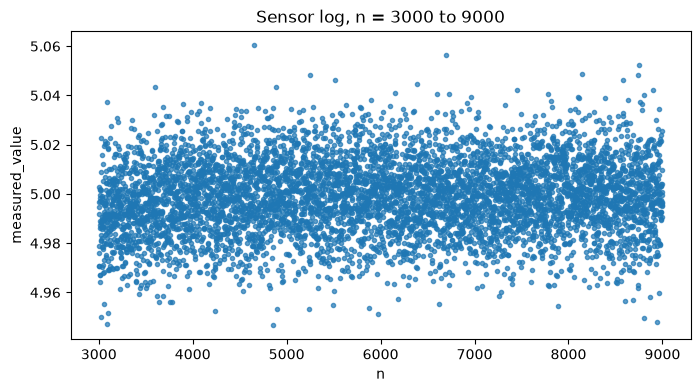

In [3]:
# EDIT HERE

n_start = 3000
n_end = 9000


#
# No need to change anything down here
#
view = df[(df['n'] >= n_start) & (df['n'] <= n_end)]
display(view)

plt.figure(figsize=(8, 4))
plt.plot(view['n'], view['measured_value'], '.', alpha=0.7)
plt.xlabel('n')
plt.ylabel('measured_value')
plt.title(f'Sensor log, n = {n_start} to {n_end}')
plt.show()



### Questions to answer before moving on

- What value does the sequence appear to be approaching? Write down your best
  guess for $L$.
- Roughly how many samples does it take before the data "settles down" near
  that value?
- Does the data ever exceed your guessed $L$, or only approach it from below?
- Try `a(n)` for a few large `n` (e.g. 7000, 8500, 9999) — does it match
  what the plot suggested?



## Task 2: The $\varepsilon$ Challenge

Your instructor assigns a value of $\varepsilon$. Using **only the data**
(no formulas, no ground truth), you must:

1. State your guessed limit `L_guess`.
2. State the smallest index `N_guess` you believe works.
3. Check your answer with `check_convergence` below, which verifies directly
   against the definition: it checks whether **every** remaining data point
   from `N_guess` onward is within `epsilon` of your `L_guess`.

Note this checks self-consistency with your own guessed $L$ — it does not
tell you the "true" limit, because the whole point is that you don't get to
see that. Two different reasonable guesses for $L$ can each have a valid $N$.

The checker also won't just hand you the smallest possible $N$: if your guess
is close (within 50), it'll tell you the exact smallest $N$; if you're
further off, it'll just tell you to try smaller.

`plot_challenge` zooms in by default: it starts a bit before your `N_guess`
and runs to the end of the data, so you can see both whether the sequence was
outside the band just before `N_guess` and that it stays inside all the way
to the end. Pass `zoom=False` if you want to see the whole sequence instead.


✓ Valid: for all n >= 2400, |a_n - 5| < 0.08.
  Close! The smallest N that works is N = 2361 (you were only 39 away).


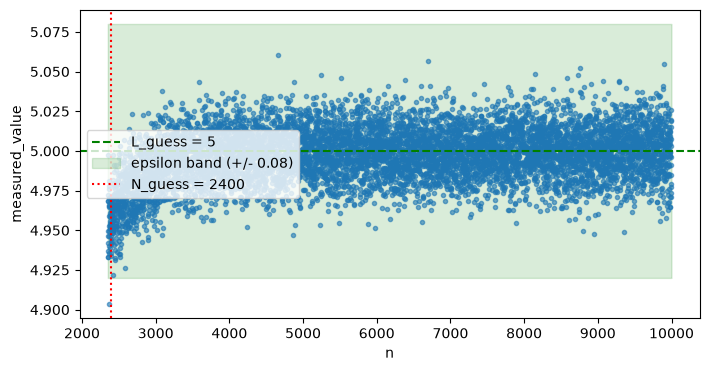

In [4]:
# --- Your answer ---
EPSILON = 0.08          # <- instructor-assigned challenge value

L_guess = 5         # TODO: your guessed limit
N_guess = 2400           # TODO: your guessed N

check_convergence(df, L_guess, N_guess, EPSILON)
plot_challenge(df, L_guess, N_guess, EPSILON)



## Dataset 2: Damped Oscillator

This time there's no CSV and no noise. Instead, you're given the sequence
directly as a **function** you can call for any index `n` — exactly the way
a sequence $(b_n)$ is usually presented in a calculus course. It models the
position of an underdamped mechanical system (e.g. a suspension, a sensor
needle) responding to a step input:

$$ b_n = x_{ss}\left(1 - e^{-\zeta \omega_n t_n}\left(\cos(\omega_d t_n) +
\frac{\zeta}{\sqrt{1-\zeta^2}}\sin(\omega_d t_n)\right)\right), \qquad t_n = n \cdot dt $$

with $\omega_d = \omega_n\sqrt{1-\zeta^2}$. Unlike Dataset 1, this sequence
**oscillates** around its limit before settling — so "getting
close once" is not enough; you have to check it *stays* close.

Since it's an exact formula (not a fixed table), you can evaluate it at
*any* `n` you like, no matter how large — there's no upper limit like there
was with `a(n)`.


In [5]:
x_ss = 2.0     # steady-state value
zeta = 0.1     # damping ratio
wn = 10.0      # natural frequency (rad/s)
wd = wn * np.sqrt(1 - zeta**2)
dt2 = 0.001    # seconds per sample

def b(n):
    """Return the n-th term of the damped step-response sequence, b_n, as a
    plain float (or array of floats if n is array-like). No noise: this is
    the exact closed-form value."""
    scalar_input = np.ndim(n) == 0
    t = np.atleast_1d(np.asarray(n, dtype=float)) * dt2
    vals = x_ss * (1 - np.exp(-zeta * wn * t) *
                    (np.cos(wd * t) + (zeta / np.sqrt(1 - zeta**2)) * np.sin(wd * t)))
    return float(vals[0]) if scalar_input else vals

# try it -- note n can be far larger than anything in Dataset 1's table:
b(0), b(3000), b(1_000_000)


(0.0, 2.0095601007352615, 2.0)


## Task 3: Explore the Sequence

Same idea as Task 1: set `n_start` and `n_end` and re-run to see a table and
plot of $b_n$ over that window. Try zooming into the first couple thousand
terms to see the oscillation, then look further out to see it settle.


,n,b_n
0,0,0.000000
1,1,0.000100
2,2,0.000399
3,3,0.000898
4,4,0.001596
...,...,...
4996,4996,1.989225
4997,4997,1.989154
4998,4998,1.989084
4999,4999,1.989015


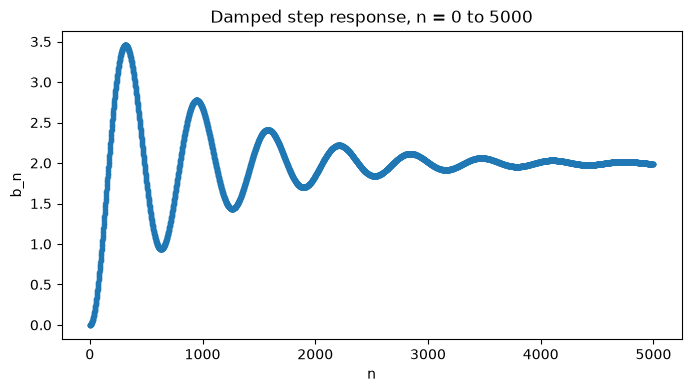

In [6]:
n_start = 0
n_end = 5000

n_vals = np.arange(n_start, n_end + 1)
view2 = pd.DataFrame({'n': n_vals, 'b_n': b(n_vals)})
display(view2)

plt.figure(figsize=(8, 4))
plt.plot(view2['n'], view2['b_n'], '.', alpha=0.7)
plt.xlabel('n')
plt.ylabel('b_n')
plt.title(f'Damped step response, n = {n_start} to {n_end}')
plt.show()



### Questions to answer before moving on

- What value does $b_n$ appear to be converging to? Compare to your guess for
  Dataset 1 — how did you decide this time, given there's no noise to average
  out?
- Around how many terms does it take before the oscillation dies down to
  something you'd call "close" to the limit?
- Pick an `n` where the plot looks close to the limit, then check a later `n`
  — does it ever swing back out? Why might that matter for choosing `N`?



## Task 4: The $\varepsilon$ Challenge, Again

Same process as Task 2 — guess `L_guess` and `N_guess` for a given
`epsilon`, and check them. The `check_convergence`, `find_smallest_N`, and
`plot_challenge` functions from Task 2 work unchanged here; we just need a
table of $b_n$ values to check against. Since $b_n$ is exact (no noise), we
can build that table out to a very large `n` — far past where anything
interesting happens — so the check is effectively verifying "forever."


✗ Not valid: at n = 3124, |a_n - 2| >= 0.08.
  The sequence leaves the epsilon-band after your N_guess. Try a larger N, or reconsider your L_guess.


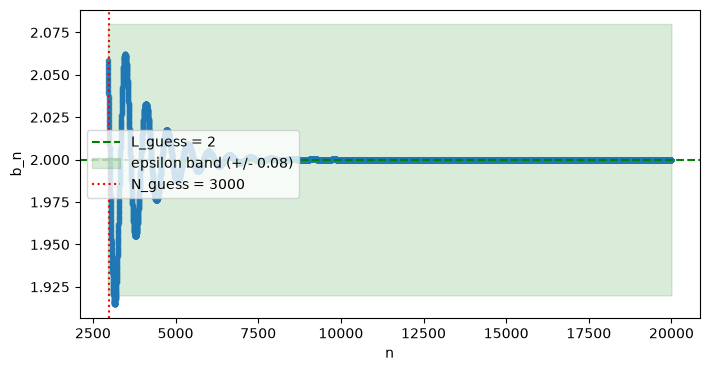

In [7]:
n_check = np.arange(0, 20000)      # generous horizon -- well past where b_n settles
osc_df = pd.DataFrame({'n': n_check, 'b_n': b(n_check)})

# --- Your answer ---
EPSILON2 = 0.08          # <- instructor-assigned challenge value

L_guess2 = 2          # TODO: your guessed limit
N_guess2 = 3000          # TODO: your guessed N

check_convergence(osc_df, L_guess2, N_guess2, EPSILON2, value_col='b_n')
plot_challenge(osc_df, L_guess2, N_guess2, EPSILON2, value_col='b_n')


## Task 5: Convergence of $\sqrt[n]{p}$

Finally, we want to study the convergence behavior of $d_n = \sqrt[n]{p}$ for various $p$. Set the parameters in the cell below.

In [8]:
# Set p
p = 2    # Experiment with different p

# Set the range of n you want to consider
d_start = 1
d_end = 100

def d(n):
    return float(p**(1/n))

As above, to return just a single term of the sequence, use `d(n)`:

In [9]:
d(2)

1.4142135623730951

Now let's plot the sequence:

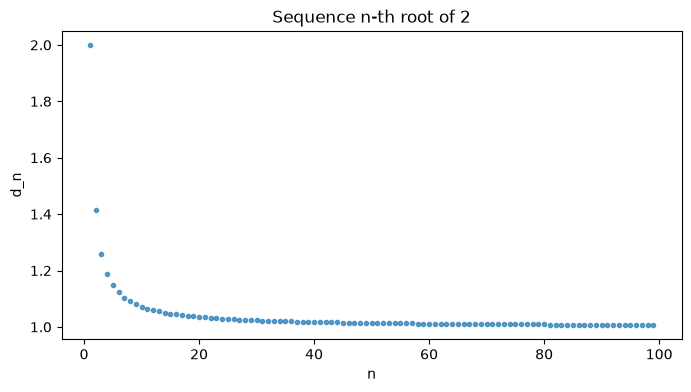

In [10]:
d_array = np.arange(d_start, d_end)
d_vals = p**(1/d_array)
view3 = pd.DataFrame({'n': d_array, 'd_n': d_vals})
# display(view3)

plt.figure(figsize=(8, 4))
plt.plot(view3['n'], view3['d_n'], '.', alpha=0.7)
plt.xlabel('n')
plt.ylabel('d_n')
plt.title(f'Sequence n-th root of {p}')
plt.show()

**Questions:** 
- Does this sequence converge for all $p>0$?
- If so, does the limit depend on $p$?